STEP 0: Install Required Libraries and Download Dataset

In [10]:
!apt-get update && apt-get install -y wget unzip
!pip install open3d imageio matplotlib opencv-python plotly --quiet

# Download and extract TUM Freiburg1_xyz dataset
!wget -q https://vision.in.tum.de/rgbd/dataset/freiburg1/rgbd_dataset_freiburg1_xyz.tgz
!tar -xzf rgbd_dataset_freiburg1_xyz.tgz

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading

STEP 1: Load RGB-D Image

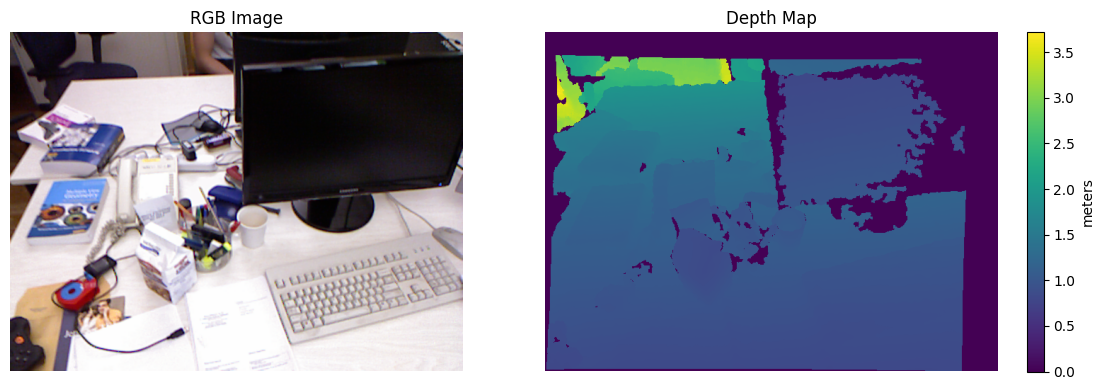

In [11]:
import os
import imageio
import numpy as np
import matplotlib.pyplot as plt

# Paths
rgb_dir = "rgbd_dataset_freiburg1_xyz/rgb"
depth_dir = "rgbd_dataset_freiburg1_xyz/depth"
rgb_files = sorted(os.listdir(rgb_dir))
depth_files = sorted(os.listdir(depth_dir))

# Load sample RGB-D image
rgb = imageio.v2.imread(os.path.join(rgb_dir, rgb_files[10]))
depth = imageio.v2.imread(os.path.join(depth_dir, depth_files[10])).astype(np.float32) / 5000.0  # in meters

# Display
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1); plt.imshow(rgb); plt.title("RGB Image"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(depth, cmap='viridis'); plt.title("Depth Map"); plt.colorbar(label='meters'); plt.axis("off")
plt.tight_layout(); plt.show()

STEP 2: Point Cloud Creation and Normal Estimation

In [12]:
import open3d as o3d

# Convert to Open3D RGBD
rgb_o3d = o3d.geometry.Image(rgb)
depth_o3d = o3d.geometry.Image((depth * 5000).astype(np.uint16))
rgbd = o3d.geometry.RGBDImage.create_from_color_and_depth(rgb_o3d, depth_o3d, depth_scale=5000.0)

# Camera intrinsics for TUM
intrinsics = o3d.camera.PinholeCameraIntrinsic(
    o3d.camera.PinholeCameraIntrinsicParameters.PrimeSenseDefault
)

# Create point cloud
pcd = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd, intrinsics)
pcd = pcd.voxel_down_sample(voxel_size=0.01)
pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamKNN(knn=30))

STEP 3: Region Growing for Planar Segmentation

In [13]:
# Perform region growing segmentation
# 📌 Perform region-based segmentation using DBSCAN (a form of density-based region growing)

with o3d.utility.VerbosityContextManager(o3d.utility.VerbosityLevel.Error) as cm:
    labels = np.array(pcd.cluster_dbscan(eps=0.1, min_points=30, print_progress=True))

max_label = labels.max()
print(f"✅ Point cloud has {max_label + 1} clusters")


# Use Open3D's built-in region growing
with o3d.utility.VerbosityContextManager(o3d.utility.VerbosityLevel.Error) as cm:
    labels = np.array(pcd.cluster_dbscan(eps=0.02, min_points=30, print_progress=True))

✅ Point cloud has 6 clusters


STEP 4: Visualize Segments with Plotly

In [14]:
import plotly.graph_objs as go

# Assign random color to each cluster label
from matplotlib import colormaps
cmap = colormaps.get_cmap("tab20")
norm_labels = (labels % 20) / 20.0
colors = cmap(norm_labels)[:, :3]  # RGB slice


# Replace noise labels (-1) with gray
colors[labels < 0] = [0.5, 0.5, 0.5]

# Create 3D scatter plot
points = np.asarray(pcd.points)
fig = go.Figure(data=[go.Scatter3d(
    x=points[:, 0], y=points[:, 1], z=points[:, 2],
    mode='markers',
    marker=dict(size=2,
                color=['rgb({},{},{})'.format(int(r*255), int(g*255), int(b*255))
                       for r, g, b in colors])
)])

fig.update_layout(title="Region Growing Segmentation on RGB-D Point Cloud (TUM)",
                  scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'))
fig.show()